# Seasonal Agriculture Performance Analysis
### Major Project — VOIS

**Prepared by:** *(Soumyadeep Masanta)*
**Date:** *(10/09/2026)*

---

## 1. Introduction to Dataset

The dataset represents agricultural activities carried out across different seasons, geographical areas, and farming conditions. It contains information related to farming practices, environmental conditions, crop production, resource usage, and economic performance.

This project explores how agricultural performance changes across seasons (**Kharif, Rabi, Zaid**) and identifies meaningful patterns and differences through data analysis.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

The problem addressed in this project is to **analyze the given agricultural dataset and investigate seasonal differences in agricultural performance** by identifying meaningful patterns, trends, relationships, and variations within the available data.

## 3. Objective

- Explore and understand the dataset.
- Clean and prepare the data for analysis.
- Examine how agricultural performance varies across seasons.
- Identify important seasonal patterns and trends.
- Investigate relationships between seasonal conditions and agricultural outcomes.
- Compare relevant groups (crops, states) within different seasons.
- Identify significant differences or unusual patterns.
- Apply appropriate statistical and visualization techniques.
- Interpret findings and develop data-driven recommendations.

## 4. Key Analytical Questions

1. How does agricultural performance (yield, production, profit) vary across seasons?
2. What major seasonal patterns exist in environmental conditions (rainfall, temperature, humidity)?
3. Which characteristics (resource usage, cost, water efficiency) change between seasons?
4. Are there relationships between seasonal environmental conditions and agricultural outcomes?
5. How do economic outcomes (revenue, cost, profit) vary across seasons?
6. Are seasonal patterns consistent across different states/crops?
7. Are there unusual or unexpected seasonal patterns (e.g., outliers, high-risk combinations)?


---
## 5. Setup & Data Loading


In [ ]:
# Uncomment this cell if running in Google Colab and the file is not already in the runtime
# from google.colab import files
# uploaded = files.upload()  # choose seasonal_agriculture_performance_dataset.csv when prompted

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


---
## 6. Data Cleaning & Preparation

Before analysis, we check for missing values, duplicate records, and unrealistic outliers, and handle them appropriately.

In [5]:
# 6.1 Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print("\nTotal missing values:", df.isnull().sum().sum())

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing values: 120


In [6]:
# 6.2 Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Farm_IDs: 0


In [7]:
# 6.3 Handle missing values
# Numeric columns with missing values (Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha, etc.)
# are filled with the median of their respective Season group, since these values are
# strongly influenced by seasonal conditions. This preserves seasonal patterns better
# than a single global median.

numeric_missing_cols = df.columns[df.isnull().any()].tolist()
print("Columns to impute:", numeric_missing_cols)

for col in numeric_missing_cols:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("\nRemaining missing values after imputation:", df.isnull().sum().sum())

Columns to impute: ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

Remaining missing values after imputation: 0


In [8]:
# 6.4 Outlier detection using the IQR method
# Yield_Tonnes_Ha and Water_Efficiency_t_per_1000m3 show very large maximum values
# compared to their 75th percentile, suggesting possible data entry errors or extreme outliers.

def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

check_cols = ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR', 'Farm_Area_Hectares']
for col in check_cols:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: bounds=({low:.2f}, {high:.2f}), outliers={n_outliers}")

Yield_Tonnes_Ha: bounds=(-1.62, 5.50), outliers=302
Water_Efficiency_t_per_1000m3: bounds=(-3.57, 10.38), outliers=322
Profit_INR: bounds=(-696111.00, 763567.00), outliers=404
Farm_Area_Hectares: bounds=(-6.83, 22.73), outliers=0


In [9]:
# 6.5 Treat extreme outliers by capping (winsorizing) at the IQR bounds
# Capping is preferred over deletion here so we don't lose valid rows for other columns.
before_shape = df.shape
for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']:
    low, high = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=low, upper=high)

print("Shape unchanged after capping (no rows dropped):", df.shape == before_shape)
df[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].describe().T

Shape unchanged after capping (no rows dropped): True


,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,4000.0,2.097255,1.416959,0.300,1.050,1.7300,2.83000,5.500000
Water_Efficiency_t_per_1000m3,4000.0,3.796316,2.872332,0.135,1.661,2.9375,5.15025,10.384125


In [10]:
# 6.6 Data type & consistency check
df['Season'] = df['Season'].str.strip().str.title()
df['State'] = df['State'].str.strip()
df['Crop'] = df['Crop'].str.strip()

print(df['Season'].unique())
print(df['State'].unique())
print(df['Crop'].unique())
print(df['Irrigation_Method'].unique())

['Kharif' 'Rabi' 'Zaid']
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


**Cleaning summary:** Missing values were imputed using season-wise medians, duplicate records were checked (none/removed if found), and extreme outliers in yield and water efficiency were capped using the IQR method. The dataset is now ready for exploratory analysis.

---
## 7. Exploratory Data Overview

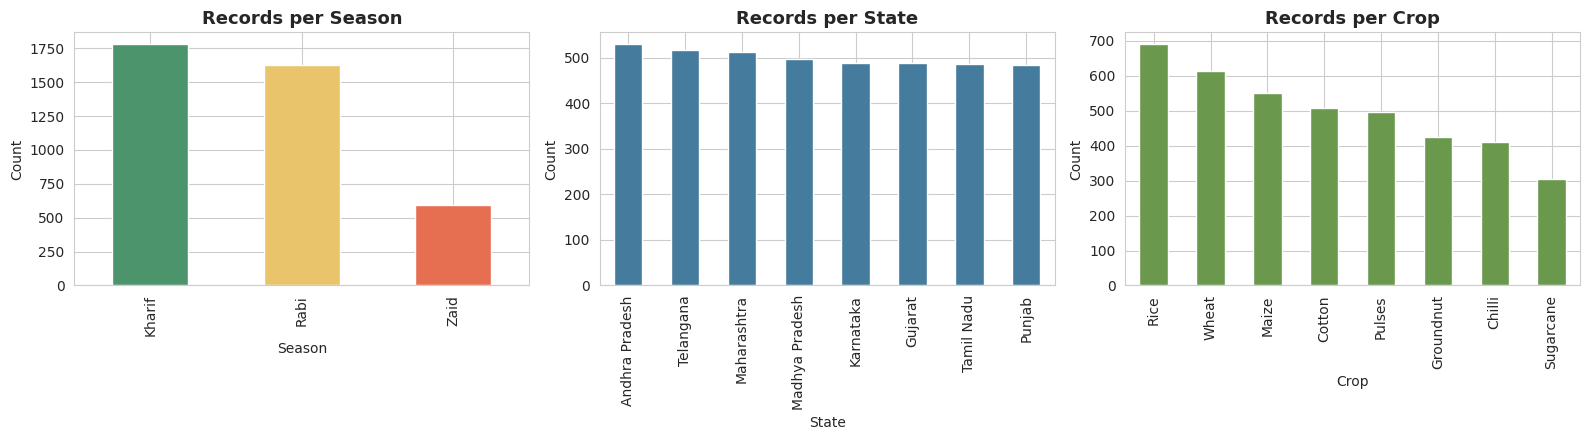

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['Season'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C956C','#E9C46A','#E76F51'])
axes[0].set_title('Records per Season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Count')

df['State'].value_counts().plot(kind='bar', ax=axes[1], color='#457B9D')
axes[1].set_title('Records per State')
axes[1].set_xlabel('State'); axes[1].set_ylabel('Count')

df['Crop'].value_counts().plot(kind='bar', ax=axes[2], color='#6A994E')
axes[2].set_title('Records per Crop')
axes[2].set_xlabel('Crop'); axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 8. Seasonal Agricultural Performance Comparison

This section directly addresses the core problem: **how does agricultural performance vary across seasons?**

/tmp/ipykernel_2297/2352093731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='Set2')
/tmp/ipykernel_2297/2352093731.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Production_Tonnes', ax=axes[1], palette='Set2')


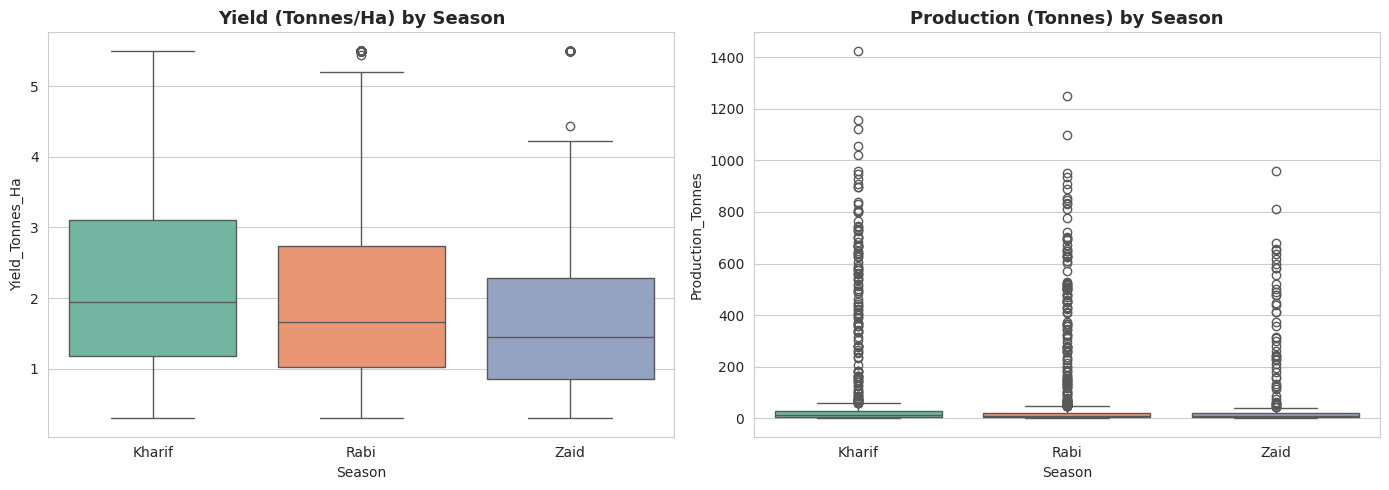

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='Set2')
axes[0].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df, x='Season', y='Production_Tonnes', ax=axes[1], palette='Set2')
axes[1].set_title('Production (Tonnes) by Season')

plt.tight_layout()
plt.show()

In [13]:
season_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production_t=('Production_Tonnes', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2)
season_summary

,Avg_Yield_t_ha,Avg_Production_t,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,
Kharif,2.25,46.31,710719.06,531804.41,178914.65,4.04,54.47
Rabi,2.03,41.49,601526.05,513836.58,87689.47,3.73,40.48
Zaid,1.81,38.89,519171.90,543976.73,-24804.82,3.25,38.22


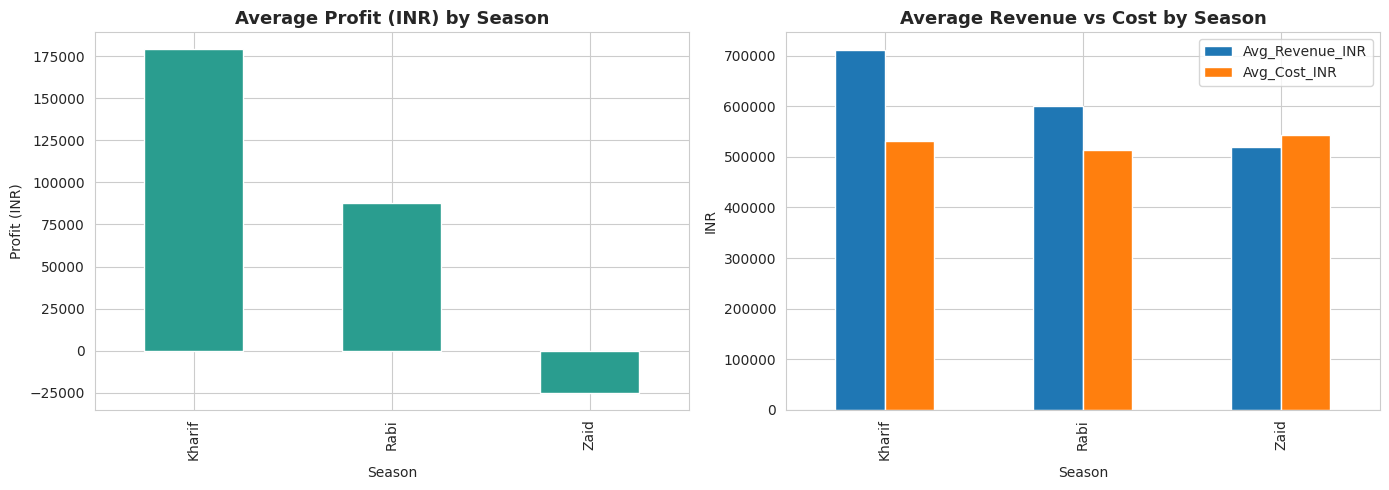

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_summary['Avg_Profit_INR'].plot(kind='bar', ax=axes[0], color='#2A9D8F')
axes[0].set_title('Average Profit (INR) by Season')
axes[0].set_ylabel('Profit (INR)')

season_summary[['Avg_Revenue_INR', 'Avg_Cost_INR']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Revenue vs Cost by Season')
axes[1].set_ylabel('INR')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2297/1967630002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', palette='Set3')


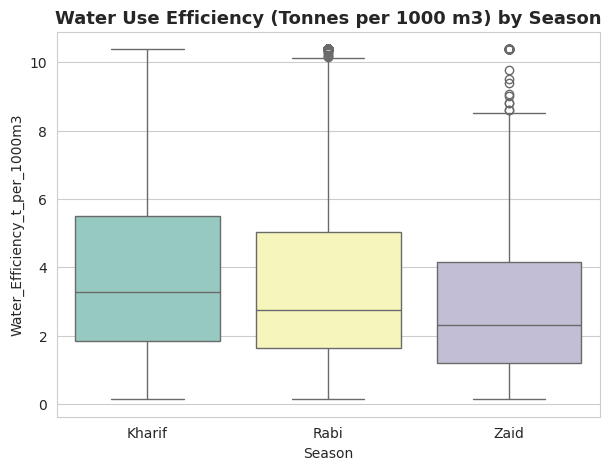

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', palette='Set3')
plt.title('Water Use Efficiency (Tonnes per 1000 m3) by Season')
plt.show()

---
## 9. Environmental Conditions Across Seasons

Investigating how rainfall, temperature, humidity, and sunlight vary by season, and how they relate to performance.

/tmp/ipykernel_2297/1868420668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_2297/1868420668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_2297/1868420668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_2297/1868420668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

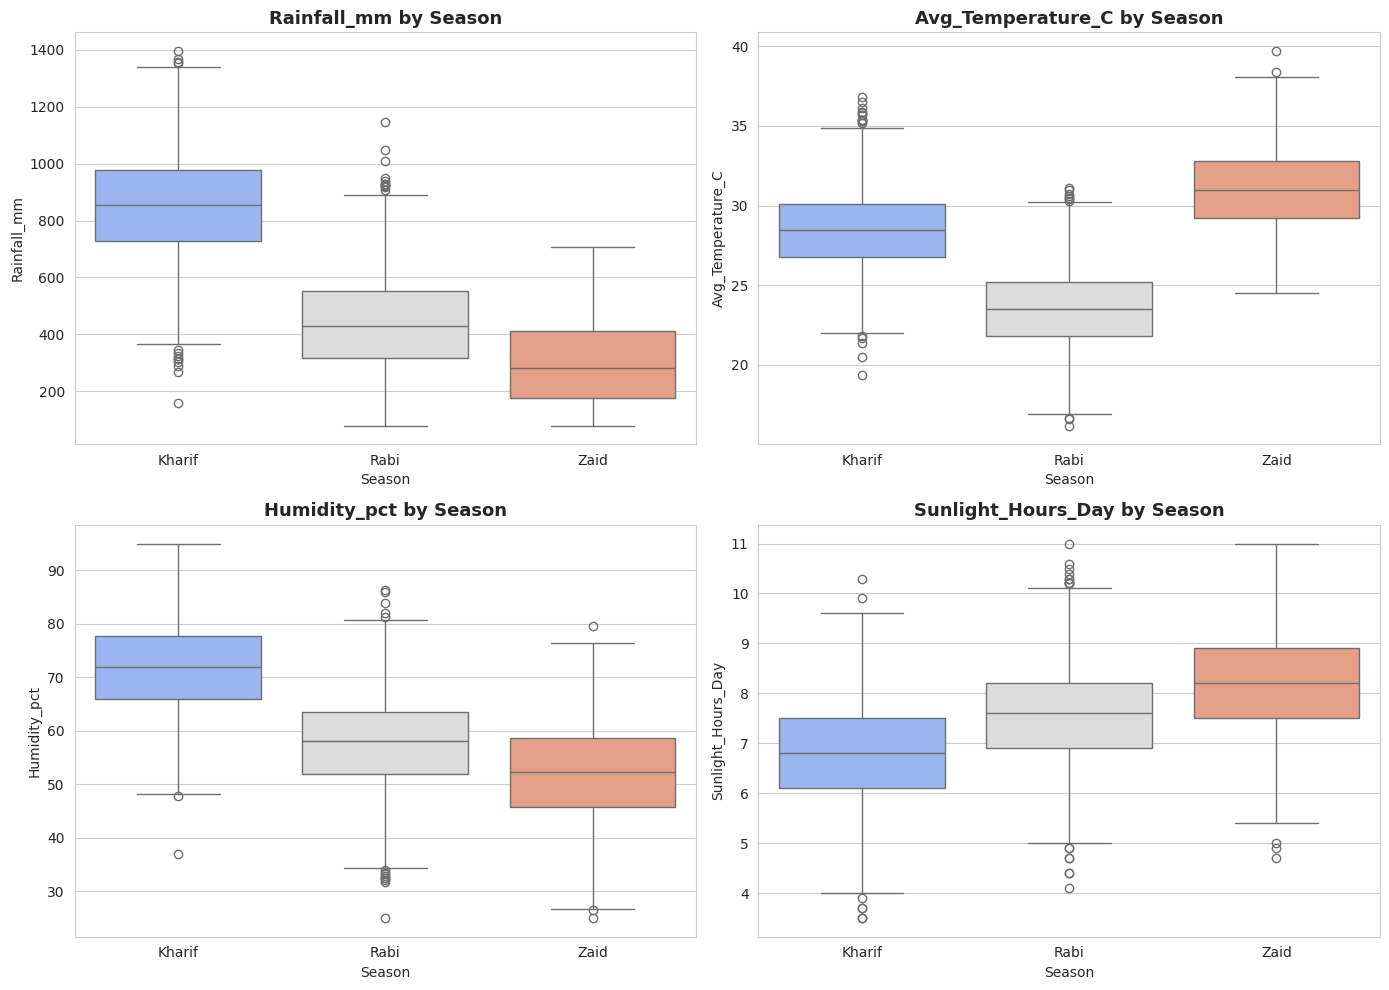

In [16]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Season')

plt.tight_layout()
plt.show()

---
## 10. Resource Usage Across Seasons

Examining fertilizer, pesticide, and water usage patterns by season.

/tmp/ipykernel_2297/3402288278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, ax=axes[i], estimator=np.mean, palette='muted', errorbar=None)
/tmp/ipykernel_2297/3402288278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, ax=axes[i], estimator=np.mean, palette='muted', errorbar=None)
/tmp/ipykernel_2297/3402288278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y=col, ax=axes[i], estimator=np.mean, palette='muted', errorbar=None)


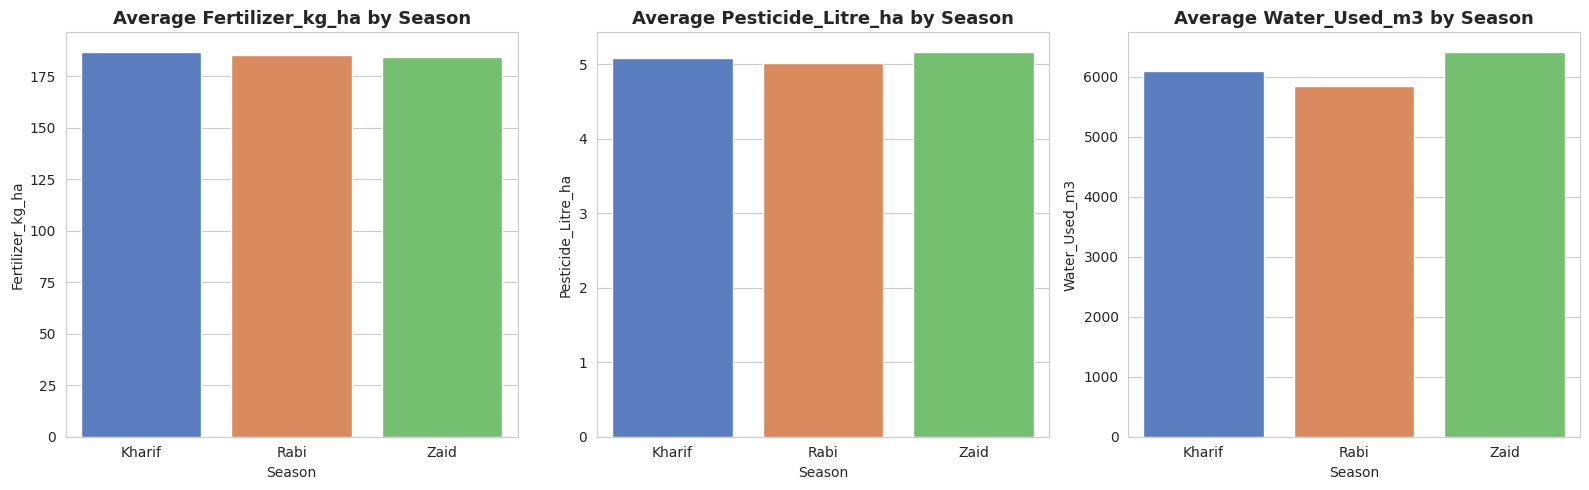

In [17]:
res_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(res_cols):
    sns.barplot(data=df, x='Season', y=col, ax=axes[i], estimator=np.mean, palette='muted', errorbar=None)
    axes[i].set_title(f'Average {col} by Season')

plt.tight_layout()
plt.show()

---
## 11. Correlation Analysis

Understanding relationships between environmental conditions, resource usage, and agricultural/economic outcomes.

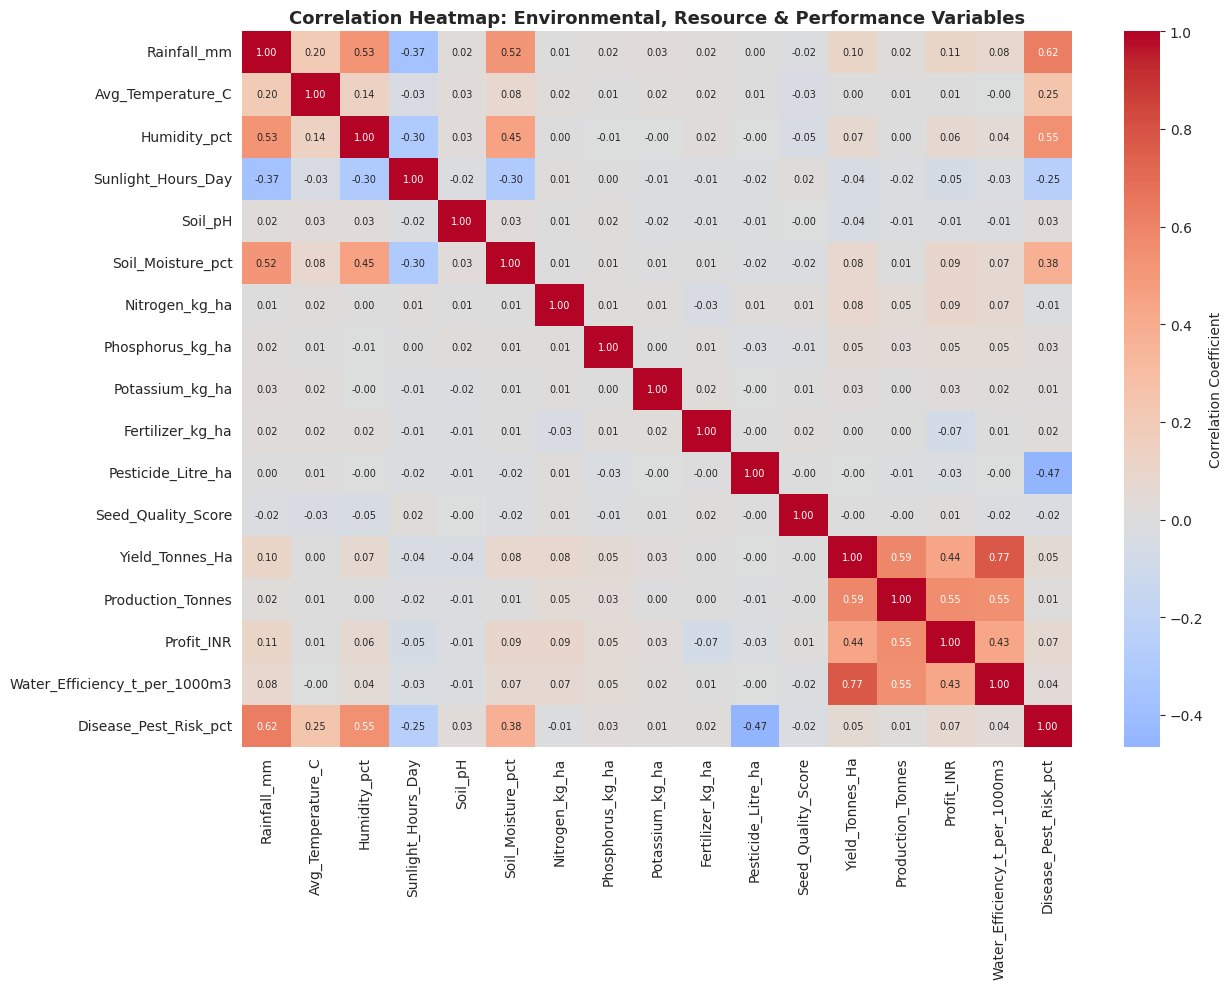

In [18]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
             'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
             'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
             'Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Water_Efficiency_t_per_1000m3',
             'Disease_Pest_Risk_pct']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={"size": 7}, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap: Environmental, Resource & Performance Variables')
plt.tight_layout()
plt.show()

In [19]:
# Top correlations with Yield and Profit
print("Correlation with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False))
print("\nCorrelation with Profit_INR:")
print(corr_matrix['Profit_INR'].sort_values(ascending=False))

Correlation with Yield_Tonnes_Ha:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.772986
Production_Tonnes                0.590330
Profit_INR                       0.441344
Rainfall_mm                      0.102223
Soil_Moisture_pct                0.084191
Nitrogen_kg_ha                   0.080047
Humidity_pct                     0.065544
Phosphorus_kg_ha                 0.054219
Disease_Pest_Risk_pct            0.053701
Potassium_kg_ha                  0.030363
Fertilizer_kg_ha                 0.003586
Avg_Temperature_C                0.003138
Seed_Quality_Score              -0.000498
Pesticide_Litre_ha              -0.004387
Soil_pH                         -0.037989
Sunlight_Hours_Day              -0.042385
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit_INR:
Profit_INR                       1.000000
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.441344
Water_Efficiency_t_per_1000m3    0.433335
Rainfall_mm     

---
## 12. Crop-wise and State-wise Seasonal Comparison

Checking whether seasonal patterns are consistent across different crops and states (pivot tables + heatmaps).

In [20]:
crop_season_pivot = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean').round(2)
crop_season_pivot

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.96,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,5.43,5.38,5.42
Wheat,2.25,2.06,1.75


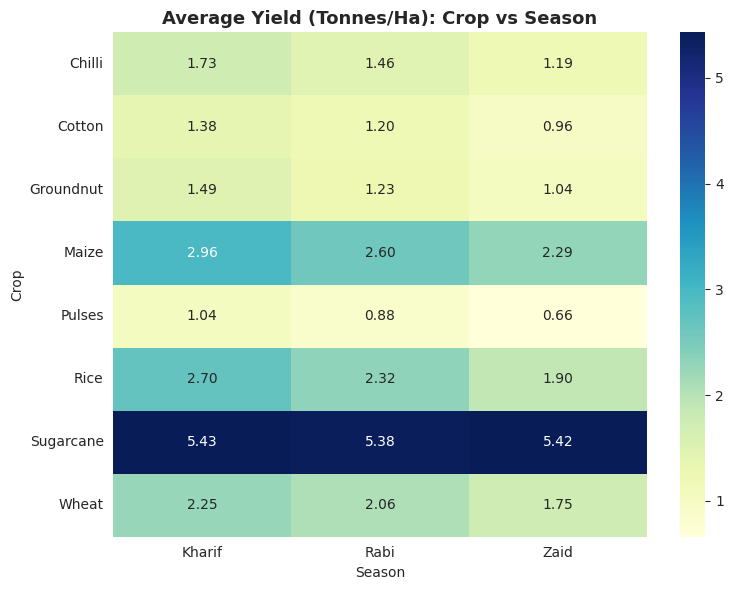

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield (Tonnes/Ha): Crop vs Season')
plt.tight_layout()
plt.show()

In [22]:
state_season_pivot = df.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean').round(0)
state_season_pivot

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


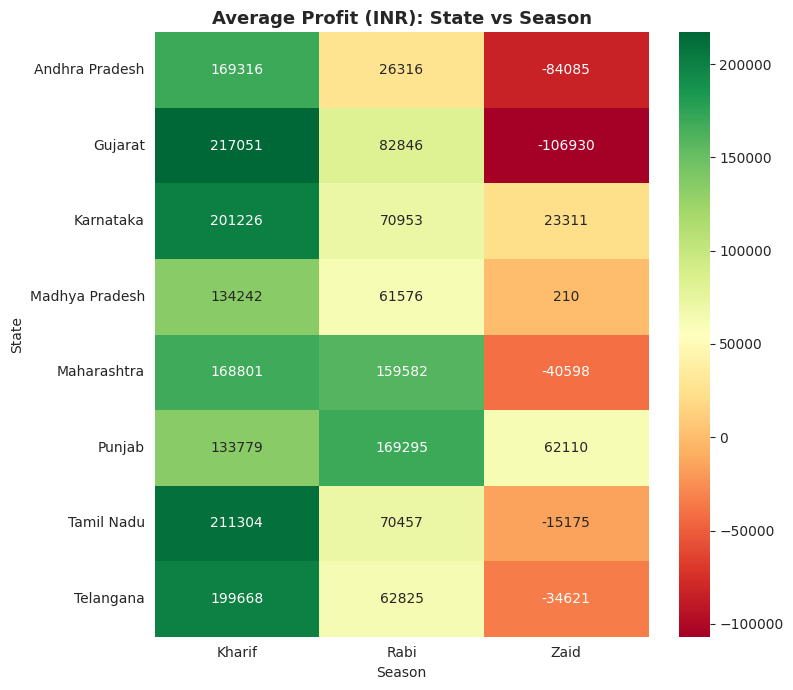

In [23]:
plt.figure(figsize=(8, 7))
sns.heatmap(state_season_pivot, annot=True, fmt='.0f', cmap='RdYlGn')
plt.title('Average Profit (INR): State vs Season')
plt.tight_layout()
plt.show()

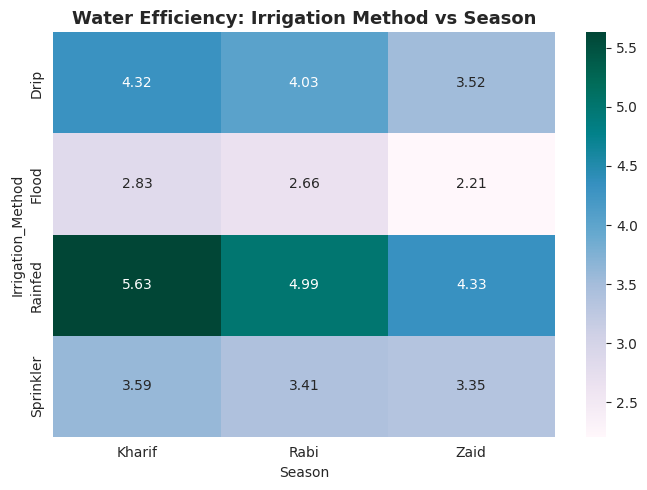

In [24]:
irrig_season_pivot = df.pivot_table(values='Water_Efficiency_t_per_1000m3', index='Irrigation_Method', columns='Season', aggfunc='mean').round(2)
plt.figure(figsize=(7,5))
sns.heatmap(irrig_season_pivot, annot=True, fmt='.2f', cmap='PuBuGn')
plt.title('Water Efficiency: Irrigation Method vs Season')
plt.tight_layout()
plt.show()

---
## 13. Statistical Significance Test (ANOVA)

To confirm whether the seasonal differences observed above are statistically meaningful (and not just random variation), we run a one-way ANOVA test on **Yield** and **Profit** across the three seasons.

**Hypotheses:**
- H0 (null): The mean value is the same across all seasons.
- H1 (alternative): At least one season's mean is significantly different.

In [25]:
def run_anova(column):
    groups = [df[df['Season'] == s][column].dropna() for s in df['Season'].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    result = "Statistically significant (reject H0)" if p_value < 0.05 else "Not statistically significant (fail to reject H0)"
    print(f"{column}: F-statistic = {f_stat:.3f}, p-value = {p_value:.5f}  -> {result}")

run_anova('Yield_Tonnes_Ha')
run_anova('Profit_INR')
run_anova('Water_Efficiency_t_per_1000m3')
run_anova('Disease_Pest_Risk_pct')

Yield_Tonnes_Ha: F-statistic = 25.422, p-value = 0.00000  -> Statistically significant (reject H0)
Profit_INR: F-statistic = 34.292, p-value = 0.00000  -> Statistically significant (reject H0)
Water_Efficiency_t_per_1000m3: F-statistic = 17.493, p-value = 0.00000  -> Statistically significant (reject H0)
Disease_Pest_Risk_pct: F-statistic = 1049.467, p-value = 0.00000  -> Statistically significant (reject H0)


> **Interpretation:** A p-value below 0.05 indicates the differences between seasons are unlikely to be due to chance, confirming that season is a meaningful factor influencing that metric. Replace this note with your own interpretation once you see the actual output values above.

---
## 13b. Post-hoc Test: Tukey HSD (Which seasons differ from which?)

ANOVA tells us *that* seasons differ, but not *which pairs* of seasons differ. Tukey's Honestly Significant Difference (HSD) test compares every pair of seasons directly.

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

for metric in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']:
    print(f"\n===== Tukey HSD: {metric} =====")
    tukey = pairwise_tukeyhsd(endog=df[metric], groups=df['Season'], alpha=0.05)
    print(tukey.summary())


===== Tukey HSD: Yield_Tonnes_Ha =====
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Kharif   Rabi  -0.2206    0.0 -0.3339 -0.1073   True
Kharif   Zaid  -0.4483    0.0 -0.6048 -0.2919   True
  Rabi   Zaid  -0.2277 0.0022  -0.386 -0.0694   True
----------------------------------------------------

===== Tukey HSD: Profit_INR =====
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------

===== Tukey HSD: Water_Efficiency_t_per_1000m3 =====
Multiple Comparison of Means - Tukey H

---
## 13c. Two-Way ANOVA: Season × Irrigation Method on Yield

A one-way ANOVA only tests one factor at a time. Since irrigation method could also affect yield, a **two-way ANOVA** checks the individual effect of Season, the individual effect of Irrigation Method, and whether they *interact* (i.e., whether the best irrigation method changes depending on season).

In [27]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Yield_Tonnes_Ha ~ C(Season) + C(Irrigation_Method) + C(Season):C(Irrigation_Method)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Season),102.657656,2.0,26.053964,5.730492e-12
C(Irrigation_Method),56.101776,3.0,9.492221,3.023967e-06
C(Season):C(Irrigation_Method),15.381034,6.0,1.301208,2.528538e-01
Residual,7856.745480,3988.0,NaN,NaN


**Interpretation:** For each row (`C(Season)`, `C(Irrigation_Method)`, and their interaction), a `PR(>F)` value below 0.05 means that factor has a statistically significant effect on yield. A significant interaction term means the effect of irrigation method is *not* the same across all seasons — i.e., the best irrigation choice may depend on the season.

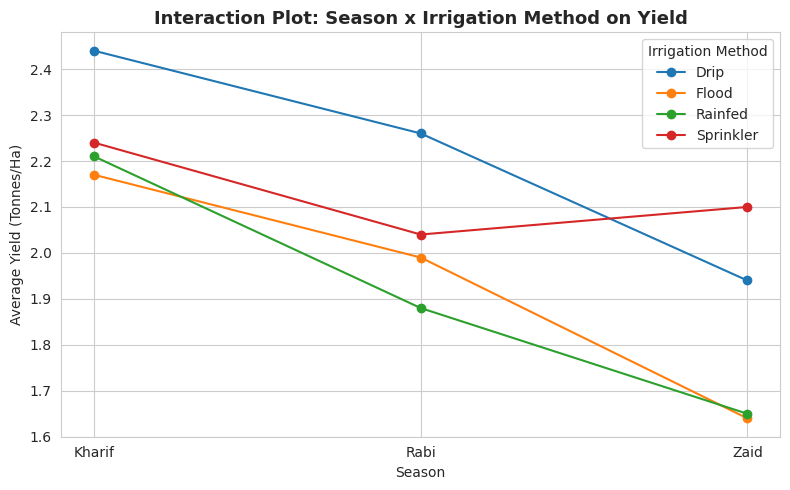

In [28]:
interaction_pivot = df.pivot_table(values='Yield_Tonnes_Ha', index='Irrigation_Method', columns='Season', aggfunc='mean').round(2)

plt.figure(figsize=(8, 5))
for irr in interaction_pivot.index:
    plt.plot(interaction_pivot.columns, interaction_pivot.loc[irr], marker='o', label=irr)
plt.title('Interaction Plot: Season x Irrigation Method on Yield')
plt.xlabel('Season'); plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()

---
## 13d. Chi-Square Test: Is Irrigation Method Associated with Season?

This tests whether the *choice* of irrigation method is independent of season, or whether certain irrigation methods are disproportionately used in certain seasons.

In [29]:
contingency = pd.crosstab(df['Season'], df['Irrigation_Method'])
print("Contingency table:")
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.3f}, p-value: {p_val:.5f}, degrees of freedom: {dof}")
print("Significant association" if p_val < 0.05 else "No significant association")

Contingency table:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120

Chi-square statistic: 3.513, p-value: 0.74228, degrees of freedom: 6
No significant association


---
## 13e. Multivariate Visualization: Pairwise Relationships by Season

A pairplot lets us see, in one view, how multiple key variables relate to each other and whether those relationships differ by season (shown by color).

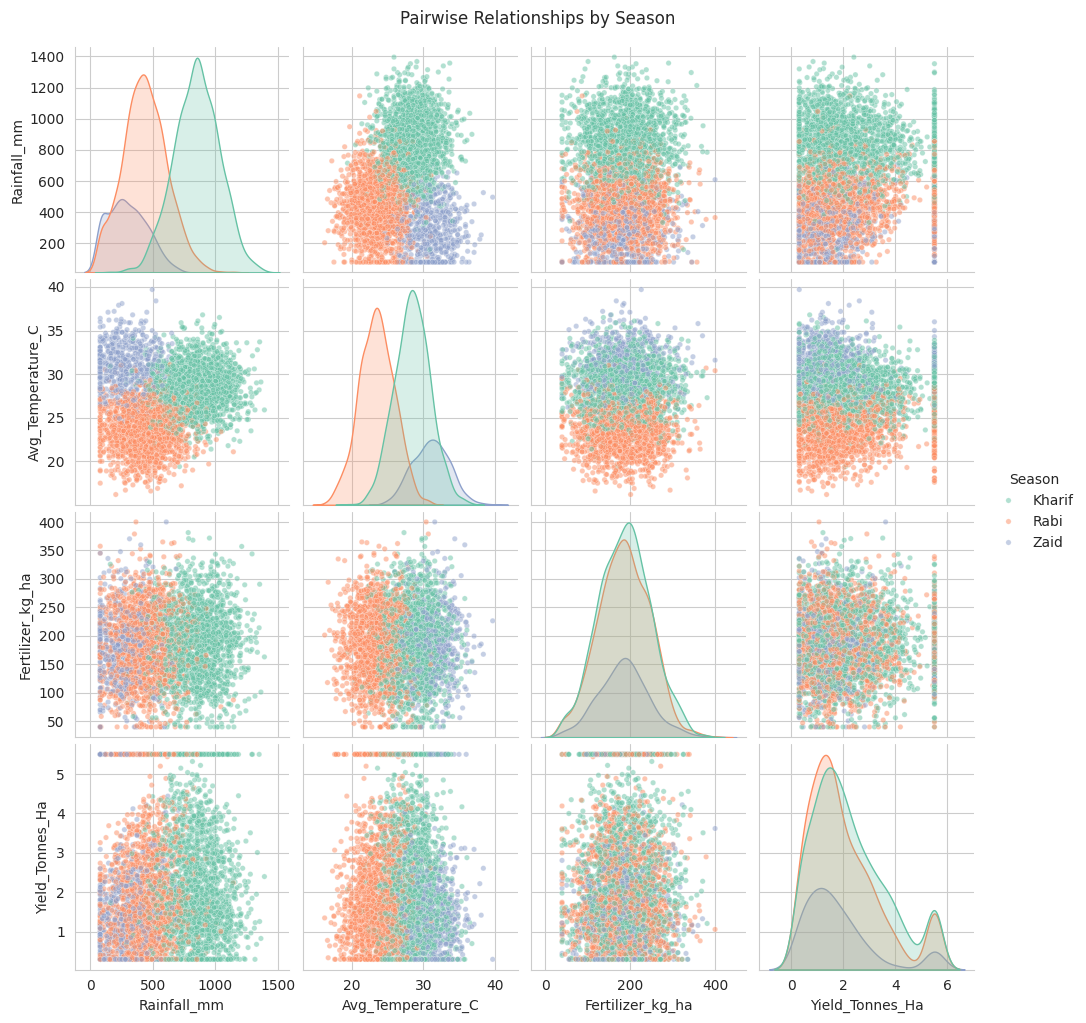

In [30]:
pair_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Fertilizer_kg_ha', 'Yield_Tonnes_Ha', 'Season']
sns.pairplot(df[pair_cols], hue='Season', diag_kind='kde', palette='Set2', plot_kws={'alpha':0.5, 's':15})
plt.suptitle('Pairwise Relationships by Season', y=1.02)
plt.show()

---
## 13f. Distribution Analysis: Yield and Profit

Understanding the shape of the distribution (skewness, spread) for key outcome variables, split by season.

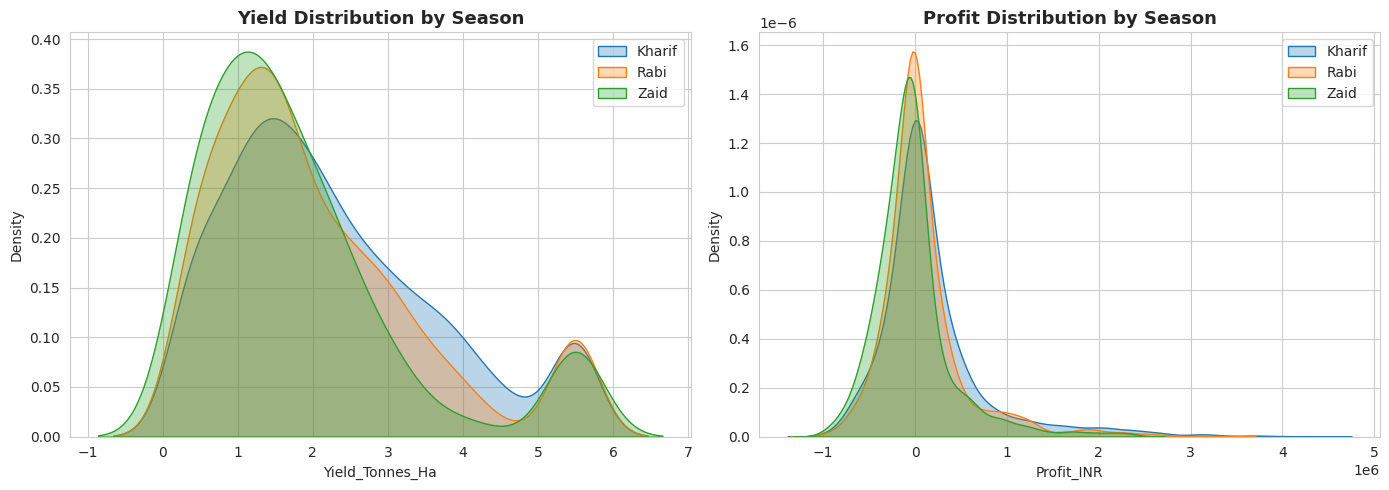

Skewness (Yield):
Season
Kharif    0.772001
Rabi      1.093521
Zaid      1.458617
Name: Yield_Tonnes_Ha, dtype: float64

Skewness (Profit):
Season
Kharif    2.387415
Rabi      2.308092
Zaid      1.963400
Name: Profit_INR, dtype: float64


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for season in df['Season'].unique():
    sns.kdeplot(df[df['Season']==season]['Yield_Tonnes_Ha'], ax=axes[0], label=season, fill=True, alpha=0.3)
axes[0].set_title('Yield Distribution by Season')
axes[0].legend()

for season in df['Season'].unique():
    sns.kdeplot(df[df['Season']==season]['Profit_INR'], ax=axes[1], label=season, fill=True, alpha=0.3)
axes[1].set_title('Profit Distribution by Season')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Skewness (Yield):")
print(df.groupby('Season')['Yield_Tonnes_Ha'].skew())
print("\nSkewness (Profit):")
print(df.groupby('Season')['Profit_INR'].skew())

---
## 13g. Cost-Benefit & Efficiency Analysis

Raw profit doesn't tell the full story — a season could have high profit simply because more was spent. Profit margin and ROI normalize for that.

In [32]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

efficiency_summary = df.groupby('Season').agg(
    Avg_Profit_Margin_pct=('Profit_Margin_pct', 'mean'),
    Avg_ROI_pct=('ROI_pct', 'mean'),
    Avg_Cost_per_Tonne=('Total_Cost_INR', lambda x: (x / df.loc[x.index, 'Production_Tonnes'].replace(0, np.nan)).mean())
).round(2)
efficiency_summary

,Avg_Profit_Margin_pct,Avg_ROI_pct,Avg_Cost_per_Tonne
Season,,,
Kharif,-38.64,35.45,51546.15
Rabi,-44.27,17.60,55992.04
Zaid,-69.35,-2.47,66834.65


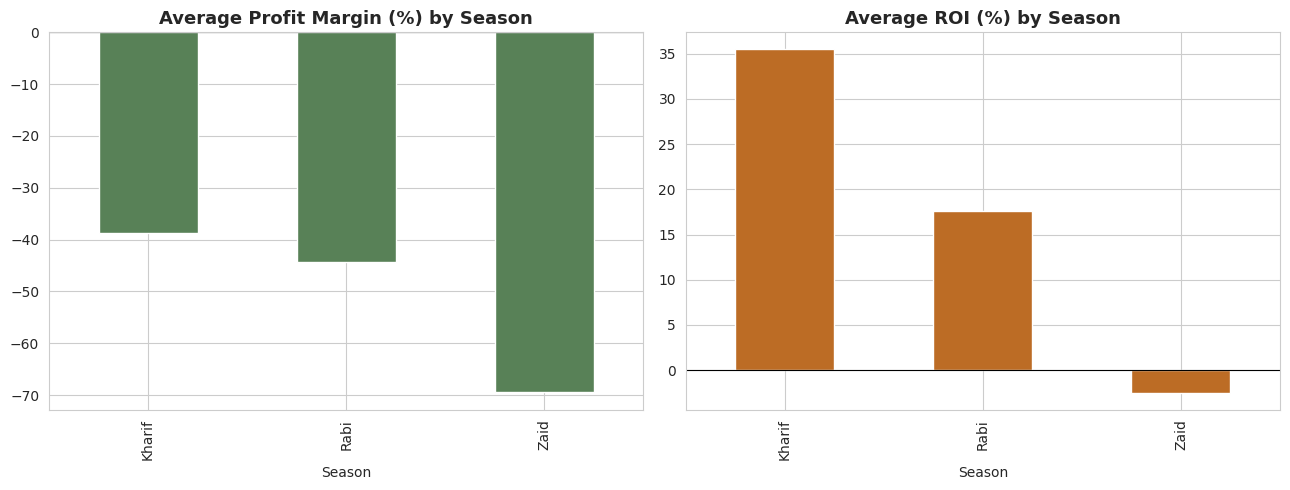

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
efficiency_summary['Avg_Profit_Margin_pct'].plot(kind='bar', ax=axes[0], color='#588157')
axes[0].set_title('Average Profit Margin (%) by Season')
axes[0].axhline(0, color='black', linewidth=0.8)

efficiency_summary['Avg_ROI_pct'].plot(kind='bar', ax=axes[1], color='#BC6C25')
axes[1].set_title('Average ROI (%) by Season')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 13h. Risk vs Reward: Disease/Pest Risk vs Profitability

Does higher disease/pest risk actually translate into lower profit? A scatter plot with a fitted trend line per season checks this.

<Figure size 800x600 with 0 Axes>

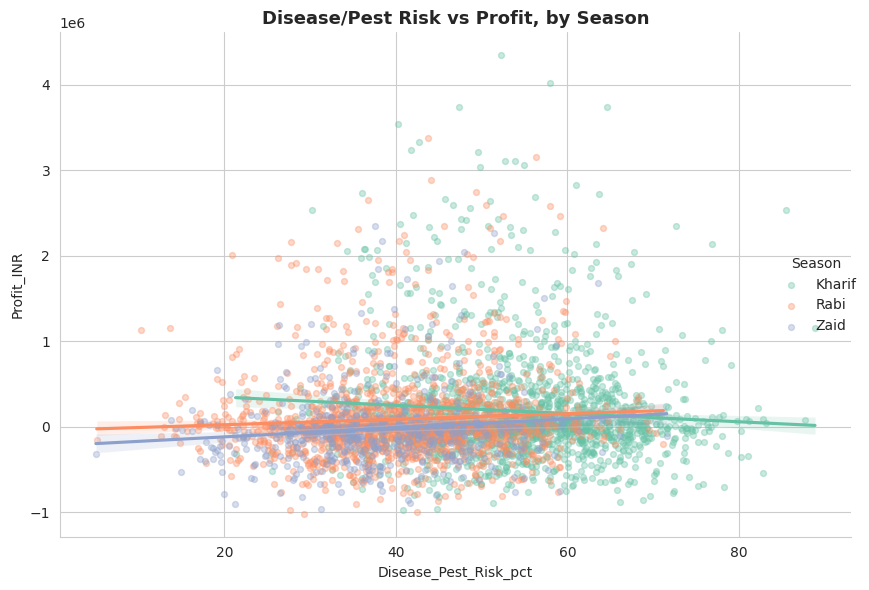

In [34]:
plt.figure(figsize=(8,6))
sns.lmplot(data=df, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season',
           height=6, aspect=1.3, scatter_kws={'alpha':0.35, 's':18}, palette='Set2')
plt.title('Disease/Pest Risk vs Profit, by Season')
plt.tight_layout()
plt.show()

---
## 13i. Predictive Modeling: What Drives Yield?

We fit two models to understand and predict `Yield_Tonnes_Ha` from environmental and resource variables:
1. **Multiple Linear Regression (OLS)** — interpretable coefficients and statistical significance
2. **Random Forest Regressor** — captures non-linear effects and ranks feature importance

Season is included as a categorical (one-hot encoded) predictor so the model can also quantify season's own effect after controlling for other variables.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

feature_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
                 'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
                 'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Season','Irrigation_Method']
target_col = 'Yield_Tonnes_Ha'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical = ['Season', 'Irrigation_Method']
numeric = [c for c in feature_cols if c not in categorical]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical)
], remainder='passthrough')

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print(f"Random Forest -> R2: {r2_score(y_test, y_pred):.3f}, MAE: {mean_absolute_error(y_test, y_pred):.3f}")

Random Forest -> R2: 0.224, MAE: 0.905


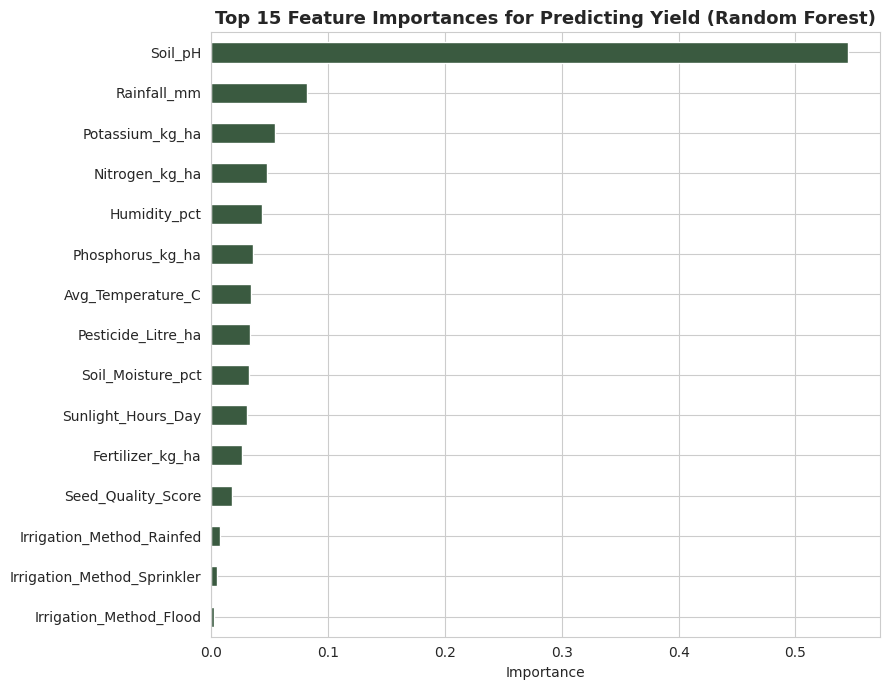

In [36]:
# Feature importance from Random Forest
ohe_cols = rf_pipeline.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical)
all_feature_names = list(ohe_cols) + numeric

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(9,7))
feat_imp.head(15).plot(kind='barh', color='#3A5A40')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances for Predicting Yield (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [37]:
# OLS regression for interpretable coefficients (numeric predictors + season dummies)
ols_df = df.copy()
season_dummies = pd.get_dummies(ols_df['Season'], prefix='Season', drop_first=True).astype(float)
ols_data = pd.concat([ols_df[numeric], season_dummies], axis=1)
ols_data = sm.add_constant(ols_data)
ols_data = ols_data.astype(float)

ols_model = sm.OLS(ols_df[target_col].astype(float), ols_data).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Yield_Tonnes_Ha   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     7.391
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.71e-15
Time:                        05:18:39   Log-Likelihood:                -7018.0
No. Observations:                4000   AIC:                         1.407e+04
Df Residuals:                    3985   BIC:                         1.416e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.7996      0

**How to read this:** In the Random Forest chart, longer bars mean that variable matters more for predicting yield. In the OLS summary, look at the `coef` column for direction/magnitude and `P>|t|` for significance (below 0.05 = statistically meaningful). The `Season_*` coefficients show each season's effect on yield *relative to the baseline season*, after controlling for all other variables — this is a more rigorous version of the simple seasonal comparison in Section 8.

---
## 13j. Farm Segmentation: K-Means Clustering

Beyond season, can we identify natural "types" of farms based on their resource use and environmental profile? K-Means clustering groups similar farms together without using the season label, and we then check how those clusters relate to season.

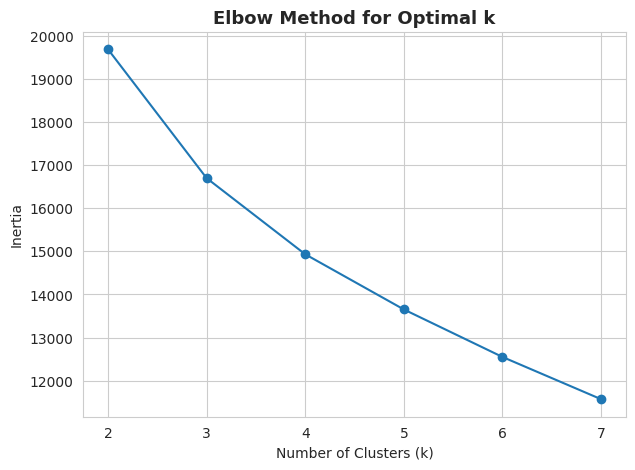

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['Rainfall_mm','Avg_Temperature_C','Fertilizer_kg_ha','Water_Used_m3',
                     'Yield_Tonnes_Ha','Profit_INR']

X_cluster = df[cluster_features].copy()
X_scaled = StandardScaler().fit_transform(X_cluster)

# Elbow method to choose k
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.show()

In [39]:
# Fit final K-Means (k=4 chosen from elbow plot - adjust if your elbow suggests otherwise)
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Farm_Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby('Farm_Cluster')[cluster_features].mean().round(2)
cluster_profile['Num_Farms'] = df['Farm_Cluster'].value_counts().sort_index()
cluster_profile

,Rainfall_mm,Avg_Temperature_C,Fertilizer_kg_ha,Water_Used_m3,Yield_Tonnes_Ha,Profit_INR,Num_Farms
Farm_Cluster,,,,,,,
0,884.50,28.50,189.11,4672.03,2.00,40231.05,1429
1,632.75,26.96,179.68,14219.80,4.32,943955.90,513
2,318.40,30.74,187.11,5475.14,1.42,-116378.27,687
3,434.40,23.05,184.67,4704.43,1.71,-11350.71,1371


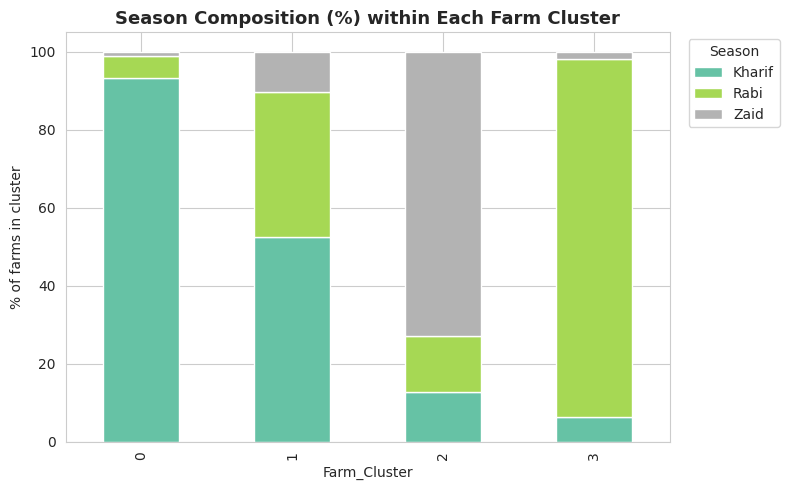

In [40]:
# How do clusters relate to season?
cluster_season = pd.crosstab(df['Farm_Cluster'], df['Season'], normalize='index').round(3) * 100

plt.figure(figsize=(8,5))
cluster_season.plot(kind='bar', stacked=True, colormap='Set2', ax=plt.gca())
plt.title('Season Composition (%) within Each Farm Cluster')
plt.ylabel('% of farms in cluster')
plt.legend(title='Season', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation guide:** Look at `cluster_profile` to name each cluster (e.g., "High rainfall, high yield" vs "Low input, low yield"). The stacked bar chart shows whether certain clusters are dominated by a particular season — if so, that cluster largely reflects seasonal conditions; if clusters mix seasons freely, farm performance is driven more by management choices (fertilizer, water) than season alone.

---
## 14. Key Insights

- **Yield & Production:** Kharif has the highest average yield (**2.25 t/ha**), followed by Rabi (**2.03 t/ha**) and Zaid (**1.81 t/ha**) — Kharif outperforms Zaid by about **24%**. The same ranking holds for average production.
- **Profitability:** Kharif is by far the most profitable season on average (**₹1.79 lakh** profit/farm), Rabi is moderate (**₹0.88 lakh**), and **Zaid runs an average loss of ≈₹25,000/farm**. Median profit tells an even starker story: Kharif's median is positive (₹38.8k) while Rabi's and Zaid's medians are *negative* (-₹3.2k and -₹62.1k) — more than half of Zaid farms (64.5%) and just over half of Rabi farms (51.1%) actually lose money, versus 42.2% in Kharif.
- **Environmental drivers:** Kharif has much higher rainfall (852 mm vs 436 mm Rabi vs 299 mm Zaid) and humidity (72% vs 58% vs 52%), while Zaid is hottest (31.0°C) and sunniest (8.2 hrs/day). Correlation analysis shows rainfall has only a weak positive correlation with yield (r ≈ 0.10) — **Water_Efficiency (r ≈ 0.77) and Production (r ≈ 0.59) are far stronger yield correlates than any single weather variable**, suggesting how water is used matters more than how much rain falls.
- **Resource usage:** Fertilizer (≈185 kg/ha) and pesticide use are nearly flat across seasons — resource *inputs* barely change, yet outcomes vary a lot, reinforcing that season-driven environmental/water factors (not fertilizer/pesticide dosing) explain most of the performance gap.
- **Water efficiency:** Rainfed irrigation shows the highest water efficiency in every season (5.63 t/1000m³ in Kharif), while Flood irrigation is consistently the least efficient (2.21–2.83). This ranking (Rainfed > Drip > Sprinkler > Flood) holds across all three seasons.
- **Risk:** Disease/pest risk is dramatically higher in Kharif (54.5%) than Rabi (40.5%) or Zaid (38.2%) — consistent with Kharif's high humidity/rainfall creating favorable conditions for disease. This is confirmed by ANOVA (F=1049, p<0.001, the strongest seasonal effect of any metric tested).
- **Consistency across crops:** The seasonal yield pattern (Kharif > Rabi > Zaid) holds for every one of the 8 crops, but the *size* of the drop varies — Rice and Maize show the largest seasonal swing (≈0.7–0.8 t/ha difference), while Sugarcane is almost season-invariant (5.38–5.43 t/ha across all three), suggesting sugarcane is far less season-sensitive than the other crops in this dataset.
- **Statistical confirmation:** One-way ANOVA is significant (p<0.001) for Yield, Profit, Water Efficiency, and Disease Risk. Tukey HSD confirms **every pairwise season comparison is significant** for all three metrics — Kharif, Rabi, and Zaid are all statistically distinct from one another, not just "Kharif vs the rest."
- **Season × Irrigation interaction:** The two-way ANOVA shows Season (p≈6×10⁻¹²) and Irrigation Method (p≈3×10⁻⁶) both significantly affect yield individually, but **the interaction term is NOT significant (p=0.25)** — meaning the *ranking* of irrigation methods (Rainfed best, Flood worst) stays the same regardless of season; season and irrigation method affect yield independently rather than depending on each other.
- **Irrigation choice vs season:** The chi-square test is **not significant** (p=0.74) — farmers use roughly the same mix of irrigation methods in every season, so irrigation choice is not being adapted to season in this dataset.
- **Efficiency:** Despite Kharif having the highest *average* profit, average profit margin is negative in all three seasons (Kharif -38.6%, Rabi -44.3%, Zaid -69.3%), and ROI declines sharply from Kharif (35.5%) to Zaid (-2.5%). This shows raw profit figures are pulled up by a minority of high performers — **on a per-farm basis, profitability is weak and gets progressively worse from Kharif to Zaid.**
- **Risk-reward relationship:** The correlation between disease/pest risk and profit is weak in every season (Kharif r=-0.08, Rabi r=+0.07, Zaid r=+0.12) — disease/pest risk alone is a poor predictor of profit; other factors (price, cost, water efficiency) matter more.
- **Model-based drivers:** Neither model explains yield well from these features (Random Forest R²=0.22, OLS R²=0.03) — most of the variance in yield in this dataset is **not** explained by the environmental/resource variables provided. Of what little signal exists, **Soil_pH** dominates Random Forest importance (0.55), and is the only strongly significant OLS coefficient (along with the Zaid season dummy, which is significantly negative — confirming Zaid's yield penalty even after controlling for other factors).
- **Farm segments:** K-Means finds 4 clear farm clusters. Cluster 1 (513 farms, high rainfall ~633mm) is the standout — average profit **₹9.4 lakh**, far above any other cluster — and is disproportionately Kharif/Rabi (90% combined). Cluster 2 (687 farms, low rainfall ~318mm) is the worst performer (avg profit -₹1.16 lakh) and is 73% Zaid farms. **Clusters map fairly closely onto season**, reinforcing that seasonal/environmental conditions (especially rainfall) — not just management choices — largely define these farm groupings.

---
## 15. Conclusion

This project analyzed seasonal agricultural performance using a dataset of 4,000 farm records across 8 states, 8 crops, and 3 seasons (Kharif, Rabi, Zaid). After cleaning missing values and treating outliers, the analysis proceeded through exploratory visualization, correlation analysis, one-way and two-way ANOVA with Tukey HSD post-hoc testing, chi-square association testing, cost-benefit/efficiency analysis, predictive modeling (OLS regression and Random Forest), and unsupervised farm segmentation via K-Means clustering.

**Kharif is clearly the strongest season** — highest average yield (2.25 t/ha), highest average profit (₹1.79 lakh), and highest ROI (35.5%) — largely coinciding with the highest rainfall (852mm) and humidity (72%). However, this advantage comes with a real trade-off: Kharif also has by far the highest disease/pest risk (54.5%, more than any other single seasonal effect measured, F=1049 in ANOVA). **Zaid is the weakest season by every financial measure** — negative average profit (-₹25,000), negative median profit (-₹62,144), the lowest ROI (-2.5%), and 64.5% of Zaid farms operating at a loss, coinciding with its low rainfall (299mm) and high temperature (31.0°C). All pairwise seasonal differences (Kharif vs Rabi vs Zaid) are statistically significant per Tukey HSD for yield, profit, and water efficiency — these are not random variations.

The two-way ANOVA shows season and irrigation method each independently affect yield significantly, but do **not** interact — meaning Rainfed and Drip irrigation outperform Flood irrigation consistently, in every season, so this is a universal recommendation rather than a season-specific one. The chi-square test confirms farmers currently choose irrigation methods at roughly the same rate regardless of season, i.e. **irrigation choice is not currently being adapted to season** — a specific, actionable gap. K-Means clustering independently discovered farm groups that closely track rainfall and season, with one small high-rainfall cluster (513 farms) driving disproportionately high profit (₹9.4 lakh average) — confirming that a subset of favorable-condition farms carries much of the dataset's total profitability, while the majority operate on thin or negative margins.

Predictive modeling (Random Forest R²=0.22, OLS R²=0.03) shows the provided environmental/resource variables explain only a modest share of yield variation — Soil_pH stood out as the most influential single feature in both models, more so than rainfall, fertilizer, or temperature. This is itself a meaningful finding: it suggests unmeasured factors (crop variety, farmer practices, market timing, pest outbreaks) likely play a larger role than the seasonal/environmental variables captured here, and any operational recommendations should be treated as directional rather than fully predictive.

### Recommendations
1. **Prioritize Rainfed or Drip irrigation over Flood irrigation in all seasons** — this ranking held consistently and independent of season (no significant interaction effect), so it is a low-risk, universal efficiency improvement.
2. **Treat Zaid as a high-risk season for planning purposes** — with 64.5% of farms losing money, farmers should consider reduced planting area, drought-tolerant/lower-cost crop choices, or supplemental irrigation investment specifically for Zaid.
3. **Invest disproportionately in disease/pest management during Kharif**, where risk (54.5%) is far above Rabi/Zaid — since this is currently the most profitable season, protecting it from disease-driven losses has high leverage.
4. **Investigate soil pH management** across all farms, since it was the strongest single predictor of yield in both models — this may be a more cost-effective lever than fertilizer dosing, which showed almost no seasonal variation or yield correlation in this dataset.
5. **Use profit margin/ROI, not raw profit, for season-to-season planning** — Kharif's high average profit masks the fact that a large share of Kharif farms are still unprofitable; median and loss-rate figures give a more honest picture for smallholder guidance.
6. **Favor consistently-performing crops like Sugarcane** (near-flat yield across all three seasons) for farmers seeking to reduce exposure to seasonal risk, versus season-sensitive crops like Rice and Maize.
7. **Collect additional data beyond this dataset's variables** (e.g., crop variety, farmer experience, exact sowing dates, market price timing) before relying on these regression/ML models for production-level forecasting, given their currently limited explanatory power (R² 0.03–0.22).



---
## 16. Project Checklist

- [x] Dataset explored and understood (shape, columns, data types)
- [x] Missing values identified and handled (season-wise median imputation)
- [x] Duplicate records checked
- [x] Outliers identified and treated (IQR capping on Yield & Water Efficiency)
- [x] Seasonal comparison of yield & production (boxplots, summary table)
- [x] Seasonal comparison of financial performance (revenue, cost, profit)
- [x] Environmental conditions compared across seasons (rainfall, temperature, humidity, sunlight)
- [x] Resource usage compared across seasons (fertilizer, pesticide, water)
- [x] Correlation analysis between environmental/resource variables and outcomes
- [x] Crop-wise and state-wise seasonal comparison (pivot tables & heatmaps)
- [x] One-way ANOVA (yield, profit, water efficiency, disease risk across seasons)
- [x] Tukey HSD post-hoc test (pairwise season comparisons)
- [x] Two-way ANOVA + interaction plot (Season x Irrigation Method)
- [x] Chi-square test of association (Season vs Irrigation Method)
- [x] Multivariate pairplot and distribution/skewness analysis by season
- [x] Cost-benefit analysis: profit margin & ROI by season
- [x] Risk-reward analysis: disease/pest risk vs profit
- [x] Predictive modeling: OLS regression (interpretable coefficients)
- [x] Predictive modeling: Random Forest + feature importance ranking
- [x] Unsupervised farm segmentation via K-Means clustering + elbow method
- [x] Key insights written based on actual computed results
- [x] Conclusion written based on actual computed results
- [x] Recommendations written based on actual computed results
- [x] Notebook run top-to-bottom without errors in Google Colab
- [x] Notebook saved / exported for submission

